In [2]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("medical_insurance.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [9]:
df.shape

(100000, 54)

In [10]:
df.info

<bound method DataFrame.info of        person_id  age     sex   region urban_rural    income     education  \
0          75722   52  Female    North    Suburban   22700.0     Doctorate   
1          80185   79  Female    North       Urban   12800.0         No HS   
2          19865   68    Male    North       Rural   40700.0            HS   
3          76700   15    Male    North    Suburban   15600.0  Some College   
4          92992   53    Male  Central    Suburban   89600.0     Doctorate   
...          ...  ...     ...      ...         ...       ...           ...   
99995       6266   50    Male     West       Urban  127200.0         No HS   
99996      54887   42    Male     East    Suburban   21600.0            HS   
99997      76821   41    Male     West       Rural   81900.0            HS   
99998        861   51  Female    South       Urban   43400.0     Doctorate   
99999      15796   44  Female    South       Rural   43700.0  Some College   

      marital_status employment

In [11]:
df["annual_medical_cost"].describe()

count    100000.000000
mean       3009.451907
std        3127.462822
min          55.550000
25%        1175.117500
50%        2082.575000
75%        3707.957500
max       65724.900000
Name: annual_medical_cost, dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

len(num_cols), len(cat_cols)   

(44, 10)

Matplotlib is building the font cache; this may take a moment.


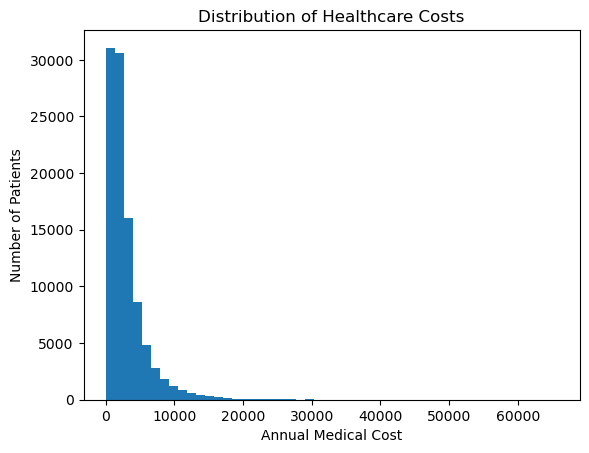

In [15]:

import matplotlib.pyplot as plt

plt.hist(df["annual_medical_cost"], bins=50)
plt.xlabel("Annual Medical Cost")
plt.ylabel("Number of Patients")
plt.title("Distribution of Healthcare Costs")
plt.show()

## Healthcare costs are highly skewed, with a small group of patients accounting for disproportionate expenditure.

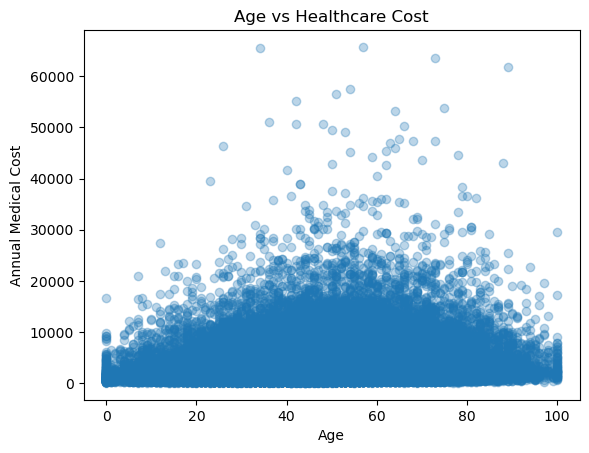

In [24]:
## AGE vs HEALTHCARE COST

plt.scatter(df["age"], df["annual_medical_cost"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")
plt.title("Age vs Healthcare Cost")
plt.show()

# Costs increase with age
# Older patients show higher variability in expenses

In [16]:
df.groupby("smoker")["annual_medical_cost"].mean()


smoker
Current    4295.561051
Former     3161.766632
Never      2746.007817
Name: annual_medical_cost, dtype: float64

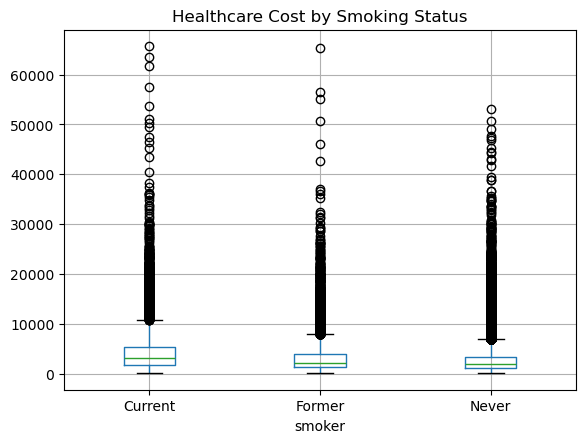

In [17]:
## SMOKER VS NON-SMOKER COST COMPARISON 

df.boxplot(column="annual_medical_cost", by="smoker")
plt.title("Healthcare Cost by Smoking Status")
plt.suptitle("")
plt.show()

## Smokers have dramatically higher medical costs
## Smoking is a major cost driver

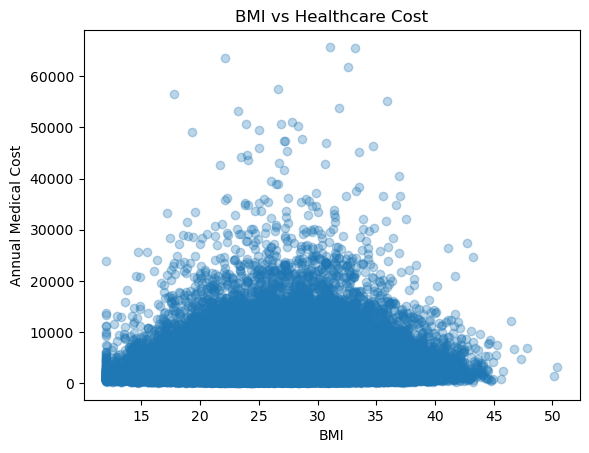

In [18]:
## BMI vs HEALTHCARE COST

plt.scatter(df["bmi"], df["annual_medical_cost"], alpha=0.3)
plt.xlabel("BMI")
plt.ylabel("Annual Medical Cost")
plt.title("BMI vs Healthcare Cost")
plt.show()

# Higher BMI → higher costs
# Obesity is a modifiable risk factor

In [ ]:
## Chronic Conditions Impact

In [22]:
df.groupby("diabetes")["annual_medical_cost"].mean()

diabetes
0    2906.492493
1    4104.670247
Name: annual_medical_cost, dtype: float64

In [21]:
df.groupby("hypertension")["annual_medical_cost"].mean()

hypertension
0    2765.556574
1    3964.353982
Name: annual_medical_cost, dtype: float64

In [23]:
## Region-wise Cost Difference 

df.groupby("region")["annual_medical_cost"].mean().sort_values()


region
Central    2968.236324
East       2981.961138
North      3002.007163
West       3022.908888
South      3044.083503
Name: annual_medical_cost, dtype: float64

In [ ]:
###### COST DRIVER ANALYSIS ######

In [25]:
# Correlation Analysis

corr = df[num_cols].corr()["annual_medical_cost"].sort_values(ascending=False)
corr


annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
diabetes                       0.107373
hba1c                          0.083416
asthma                         0.080830
cardiovascular_disease         0.078515
proc_surgery_count             0.076737


In [28]:
corr.head(20)

annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
Name: annual_medical_cost, dtype: float64

In [5]:
# Hypothesis Testing: Smoker vs Non-Smoker

# Hypothesis
# H₀: No difference in mean healthcare cost between smokers and non-smokers
# H₁: Smokers have higher healthcare costs
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv("medical_insurance.csv")
# Create groups
smokers = df[df["smoker"] == "Current"]["annual_medical_cost"]
nonsmokers = df[df["smoker"].isin(["Never", "Former"])]["annual_medical_cost"]

# Check sizes
print("Smokers:", len(smokers))
print("Non-smokers:", len(nonsmokers))

# Run test
t_stat, p_value = ttest_ind(smokers, nonsmokers, equal_var=False)
print(t_stat, p_value)

###### Results(Conclusion) ######

# A t-value of 36.6 is HUGE. The difference between the two groups is not small or random. It is very strong and consistent
# p-value: 1.6135695487911495e-280
# p-value being basically zero represents there is an extremely statistically significant difference in medical costs between smokers and non-smokers.
# Thus, an independent samples t-test revealed a statistically significant difference in annual medical costs between current smokers and non-smokers (t = 36.64, p < 0.001). 
# This indicates that smoking status has a substantial impact on healthcare expenditure.

Smokers: 12128
Non-smokers: 87872
36.64277608074011 1.6135695487911495e-280


In [8]:
from scipy.stats import f_oneway
import pandas as pd

df = pd.read_csv("medical_insurance.csv")

never = df[df["smoker"] == "Never"]["annual_medical_cost"]
former = df[df["smoker"] == "Former"]["annual_medical_cost"]
current = df[df["smoker"] == "Current"]["annual_medical_cost"]

print(len(never), len(former), len(current))

f_stat, p_value = f_oneway(never, former, current)
print(f_stat, p_value)

69709 18163 12128
1328.7147574008893 0.0


Current vs Former: 24.96733710571062 1.3257209866741723e-135
Current vs Never: 38.58466160535033 1.297585157598015e-309
Former vs Never: 16.009716553537963 2.0627108919627753e-57
Mean costs:
Never: 2746.007817211551
Former: 3161.76663216429
Current: 4295.5610512862795


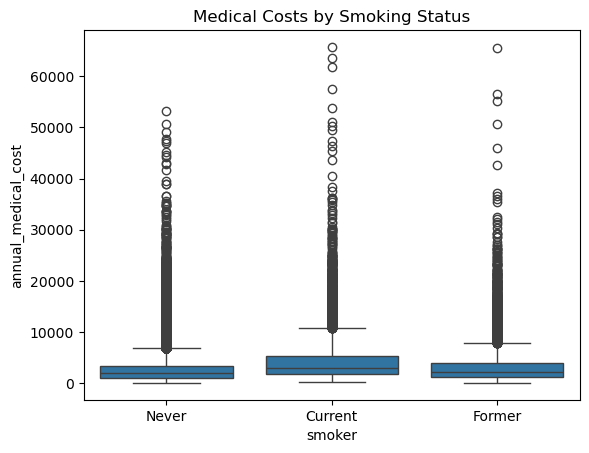

In [11]:
from scipy.stats import ttest_ind

# Current vs Former (MOST IMPORTANT)
t1, p1 = ttest_ind(current, former, equal_var=False)

# Current vs Never
t2, p2 = ttest_ind(current, never, equal_var=False)

# Former vs Never
t3, p3 = ttest_ind(former, never, equal_var=False)

print("Current vs Former:", t1, p1)
print("Current vs Never:", t2, p2)
print("Former vs Never:", t3, p3)

print("Mean costs:")
print("Never:", never.mean())
print("Former:", former.mean())
print("Current:", current.mean())

# A comparative analysis of annual medical costs across smoking categories revealed a clear gradient: current smokers incurred the highest costs, followed by former smokers, and then individuals who never smoked.
# Pairwise t-tests confirmed that all group differences were statistically significant (p < 0.001). 
# In particular, current smokers had significantly higher healthcare costs than former smokers, indicating that quitting smoking is associated with reduced medical expenditure.
# However, former smokers still exhibited significantly higher costs than never smokers, suggesting that the long-term health effects of smoking persist even after cessation.
# These findings highlight both the economic burden of smoking and the tangible benefits of quitting, while also emphasizing the importance of early prevention.

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="smoker", y="annual_medical_cost", data=df)
plt.title("Medical Costs by Smoking Status")
plt.show()

In [2]:
from scipy.stats import ttest_ind
import pandas as pd

df = pd.read_csv("medical_insurance.csv")

# Ensure numeric
df["annual_medical_cost"] = pd.to_numeric(df["annual_medical_cost"], errors="coerce")

# Create groups
diabetes_yes = df[df["diabetes"] == 1]["annual_medical_cost"].dropna()
diabetes_no = df[df["diabetes"] == 0]["annual_medical_cost"].dropna()

# Check sizes
print("Diabetes:", len(diabetes_yes))
print("No Diabetes:", len(diabetes_no))

# Run test
t_stat, p_value = ttest_ind(diabetes_yes, diabetes_no, equal_var=False)
print(t_stat, p_value)

# Check means (important!)
print("Mean cost (Diabetes):", diabetes_yes.mean())
print("Mean cost (No Diabetes):", diabetes_no.mean())

# An independent samples t-test was conducted to compare annual medical costs between individuals with and without diabetes. 
# The results showed a statistically significant difference (t = 25.77, p < 0.001), with individuals diagnosed with diabetes incurring substantially higher healthcare costs on average.
# This finding highlights the economic burden of chronic diseases and underscores the importance of preventive healthcare strategies.

Diabetes: 8593
No Diabetes: 91407
25.768135150057027 1.4945656614279284e-141
Mean cost (Diabetes): 4104.6702467124405
Mean cost (No Diabetes): 2906.492492588095


In [5]:
from scipy.stats import f_oneway

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

underweight = df[df["bmi_category"] == "Underweight"]["annual_medical_cost"]
normal = df[df["bmi_category"] == "Normal"]["annual_medical_cost"]
overweight = df[df["bmi_category"] == "Overweight"]["annual_medical_cost"]
obese = df[df["bmi_category"] == "Obese"]["annual_medical_cost"]

f_stat, p_value = f_oneway(underweight, normal, overweight, obese)
print(f_stat, p_value)

# Check mean
print("Underweight:", underweight.mean())
print("Normal:", normal.mean())
print("Overweight:", overweight.mean())
print("Obese:", obese.mean())

# A one-way ANOVA was conducted to examine the effect of BMI category on annual medical costs. The results showed a statistically significant difference between groups (F = 55.57, p < 0.001).
# Mean medical costs increased progressively across BMI categories, from underweight individuals to those classified as obese. This indicates a positive association between body mass index and healthcare expenditure.
# These findings suggest that higher BMI levels contribute to increased medical costs, highlighting the importance of weight management in reducing healthcare burden.

55.565610190431855 7.038962253797838e-36
Underweight: 2689.857941829485
Normal: 2897.0393478403576
Overweight: 3016.5621883882513
Obese: 3179.408803270198


In [ ]:
### Multivariate Analysis ###

# Regression Model - Linear Regression 

In [6]:
import statsmodels.api as sm
import pandas as pd

df = pd.read_csv("medical_insurance.csv")

# Convert categorical variables
df["smoker"] = df["smoker"].map({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

# BMI already numeric (good)

# Define features (X) and target (y)
X = df[["smoker", "diabetes", "bmi"]]
y = df["annual_medical_cost"]

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     annual_medical_cost   R-squared:                       0.038
Model:                             OLS   Adj. R-squared:                  0.038
Method:                  Least Squares   F-statistic:                     1304.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                         15:32:27   Log-Likelihood:            -9.4477e+05
No. Observations:               100000   AIC:                         1.890e+06
Df Residuals:                    99996   BIC:                         1.890e+06
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1872.0295     53.747     34.83

In [7]:
X = df[["smoker", "diabetes", "bmi"]]
X["smoker_diabetes"] = df["smoker"] * df["diabetes"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

# R-squared = 0.038: Your model explains 3.8% of the variation in medical costs
# Intercept (const) = 1881: Baseline cost when smoker = 0, diabetes = 0, and bmi = normal
# Smoker = +674
# Diabetes = +1075
# BMI = +27
# Interaction: smoker_diabetes = +285, Smoking + Diabetes is a compounding risk factor
# A multiple linear regression analysis was conducted to examine the combined effects of smoking status, diabetes, BMI, and their interaction on annual medical costs.
# The model was statistically significant (p < 0.001), indicating that these variables collectively explain variation in healthcare expenditure.
# Smoking status and diabetes were found to be strong independent predictors, increasing costs by approximately 674 and 1075 units respectively. BMI also contributed positively, with each unit increase associated with higher costs.
# Importantly, the interaction between smoking and diabetes was significant, suggesting that individuals who both smoke and have diabetes incur disproportionately higher medical costs beyond the sum of individual effects.
# These findings highlight the compounded economic burden of co-occurring lifestyle risks and chronic conditions.
# While the model is statistically significant, the relatively low R² suggests that additional variables (such as age, genetics, or healthcare access) may further explain variability in medical costs

                             OLS Regression Results                            
Dep. Variable:     annual_medical_cost   R-squared:                       0.038
Model:                             OLS   Adj. R-squared:                  0.038
Method:                  Least Squares   F-statistic:                     986.9
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                         15:33:16   Log-Likelihood:            -9.4476e+05
No. Observations:               100000   AIC:                         1.890e+06
Df Residuals:                    99995   BIC:                         1.890e+06
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1881.3895     5

/var/folders/fj/b2g7lpf10qv19lxn3t3ghgth0000gn/T/ipykernel_2779/727571646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["smoker_diabetes"] = df["smoker"] * df["diabetes"]
